<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
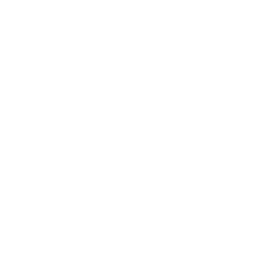
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse af læseplanslighed</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Videregående uddannelse / Design af studieprogrammer &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning for ledelsen

Denne notebook måler læseplansoverlap på tværs af et universitets kursuskatalog med **PROC DISTANCE** og **METHOD=DJACCARD** — Jaccard-*dissimilaritets*koefficienten, den naturlige afstand for binære til stede/fraværende-data. Hvert kursus bærer 40 binære flag, der markerer, hvilke akkrediteringslæringsmål det dækker, så Jaccard-afstanden mellem to kurser er andelen af dækkede mål, de **ikke** har til fælles (0 = identiske målmængder, 1 = intet fælles mål).

Analysen kører i to dele. Først profilerer den, på tværs af et katalog med 100 kurser, bredden af måldækning pr. afdeling (PROC MEANS, PROC FREQ, et boksplot over dækning) og markerer læringsmål, som **intet** kursus i en afdeling dækker (dækningshuller). Dernæst borer den ned i et fokuseret panel på 10 kurser trukket fra de to mest kvantitativt overlappende afdelinger — Statistik og Data Science — beregner den fulde parvise Jaccard-afstandsmatrix og rangordner de tætteste kursuspar som kandidater til konsolideringsgennemgang. Målet er at give et læseplansudvalg to konkrete artefakter: en rangordnet liste over de mest ens kurser og et kort over huller pr. afdeling og mål.

## Datakilder

| Kilde | Beskrivelse | Antal poster |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binær læringsmåldækning pr. kursus (40 målflag) | 100 |
| WORK.PANEL10 | Konsolideringspanel for Statistik + Data Science | 10 |

Kataloget er syntetisk. Målflag trækkes med afdelingsspecifikke sandsynligheder, så discipliner lægger vægt på forskellige målklynger (datalogi og matematik vægter de tidlige mål, laboratoriefagene vægter det midterste bånd), hvilket giver afstandsanalysen realistisk struktur. Dette miljø kører uden licens, så arbejdskataloget er begrænset til 100 kurser.

---

In [1]:
/* --------------------------------------------------------
   Generér syntetisk kursus-læringsmålmatrix
   500 kurser x 40 akkrediteringslæringsmål
   (ulicenseret tilstand beholder de første 100)
   -------------------------------------------------------- */
data work.course_outcomes;
    CALL streaminit(42);
    TABEL outcomes[40] lo_1 - lo_40;
    LÆNGDE department $20;
    GØR course_id = 1 TIL 500;
        course_label = cat('CRS', SKRIV_V(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        VÆLG (dept_idx);
            NÅR (1) department = 'Datalogi';
            NÅR (2) department = 'Matematik';
            NÅR (3) department = 'Statistik';
            NÅR (4) department = 'Ingeniørvidenskab';
            NÅR (5) department = 'Biologi';
            NÅR (6) department = 'Kemi';
            NÅR (7) department = 'Fysik';
            ELLERS_OM department = 'Data Science';
        SLUT;
        /* Kursusniveau påvirker målbredden */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Afdelingsspecifikke målklynger */
        GØR lo = 1 TIL 40;
            base_prob = 0.15;
            /* Afd. 1-2 (Datalogi, Matematik): vægt mål 1-15 */
            HVIS dept_idx <= 2 AND lo <= 15 SÅ
                base_prob = 0.4 + course_level * 0.05;
            /* Afd. 3-4 (Statistik, Ingeniør): vægt mål 10-25 */
            ELLERS HVIS dept_idx IN (3, 4) AND 10 <= lo <= 25 SÅ
                base_prob = 0.35 + course_level * 0.05;
            /* Afd. 5-7 (Biologi, Kemi, Fysik): vægt mål 20-35 */
            ELLERS HVIS dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 SÅ
                base_prob = 0.38 + course_level * 0.04;
            /* Afd. 8 (Data Science): bred dækning */
            ELLERS HVIS dept_idx = 8 SÅ
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        SLUT;
        UDDATA;
    SLUT;
    FJERN dept_idx course_level base_prob lo;
KØR;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds


In [2]:
/* --------------------------------------------------------
   Generér metadata for kursuskatalog
   -------------------------------------------------------- */
data work.course_catalog;
    CALL streaminit(43);
    LÆNGDE department $20 delivery_format $15;
    GØR course_id = 1 TIL 500;
        course_label = cat('CRS-', SKRIV_V(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        VÆLG (dept_idx);
            NÅR (1) department = 'Datalogi';
            NÅR (2) department = 'Matematik';
            NÅR (3) department = 'Statistik';
            NÅR (4) department = 'Ingeniørvidenskab';
            NÅR (5) department = 'Biologi';
            NÅR (6) department = 'Kemi';
            NÅR (7) department = 'Fysik';
            ELLERS_OM department = 'Data Science';
        SLUT;
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        VÆLG (format_idx);
            NÅR (1) delivery_format = 'Forelæsning';
            NÅR (2) delivery_format = 'Laboratorium';
            ELLERS_OM delivery_format = 'Seminar';
        SLUT;
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        UDDATA;
    SLUT;
    FJERN dept_idx format_idx;
    format last_offered date9.;
KØR;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


---

                                            Baseline-måldækning pr. afdeling                                            

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                                N
                                        Afdeling              Obs           Mean
                                        ----------------------------------------
                                        Biologi                10      0.2000000
                                        Data Science           14      0.1428571
                                        Datalogi               13      0.3846154
                                        Fysik                   7      0.2857143
                                        Ingeniørvidenskab      17      0.0000000
                                        Kemi                   19      0.2105263
                    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


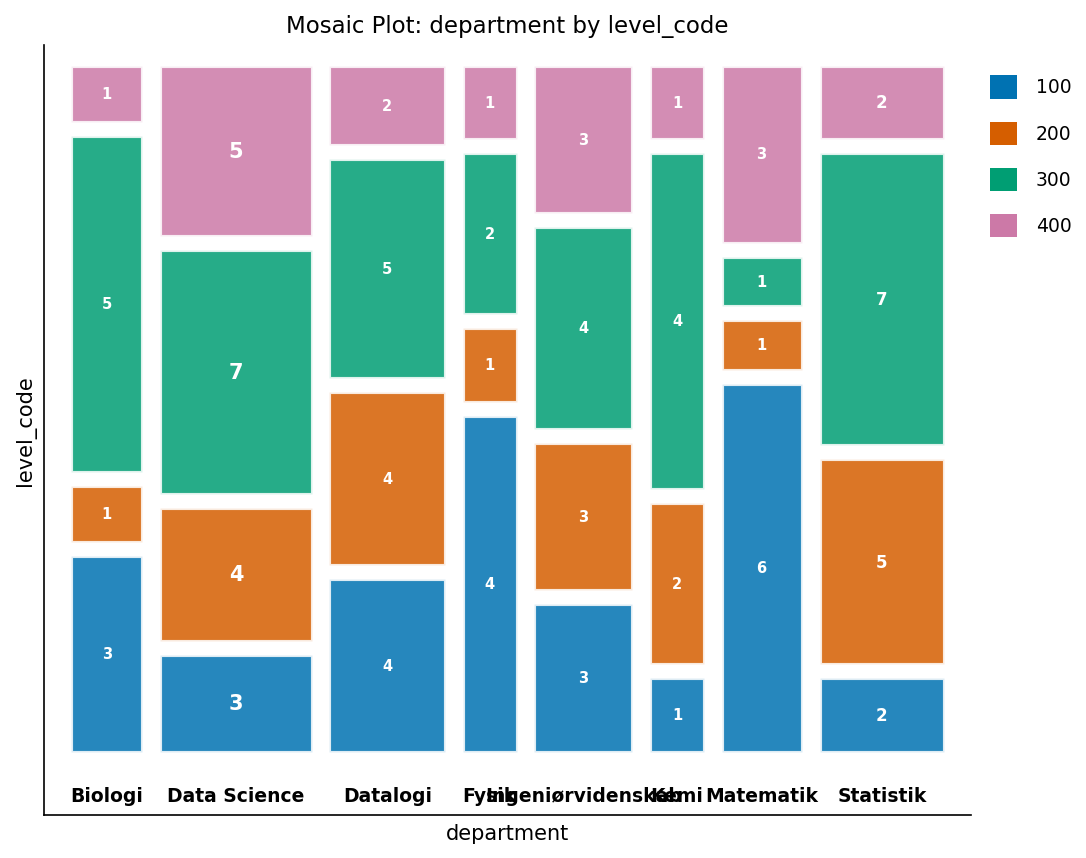

In [3]:
/* --------------------------------------------------------
   Baseline-læringsmåldækning pr. afdeling
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.course_outcomes mean;
    KLASSE department;
    VARIABEL lo_1 - lo_40;
    MÆRKAT department='Afdeling';
    TITEL 'Baseline-måldækning pr. afdeling';
KØR;

PROCEDURE FREKVENSER data=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    MÆRKAT department='Afdeling' level_code='Niveau';
    TITEL 'Kursusfordeling: afdeling efter niveau';
KØR;

---

                                         Kursusfordeling: afdeling efter niveau                                         




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


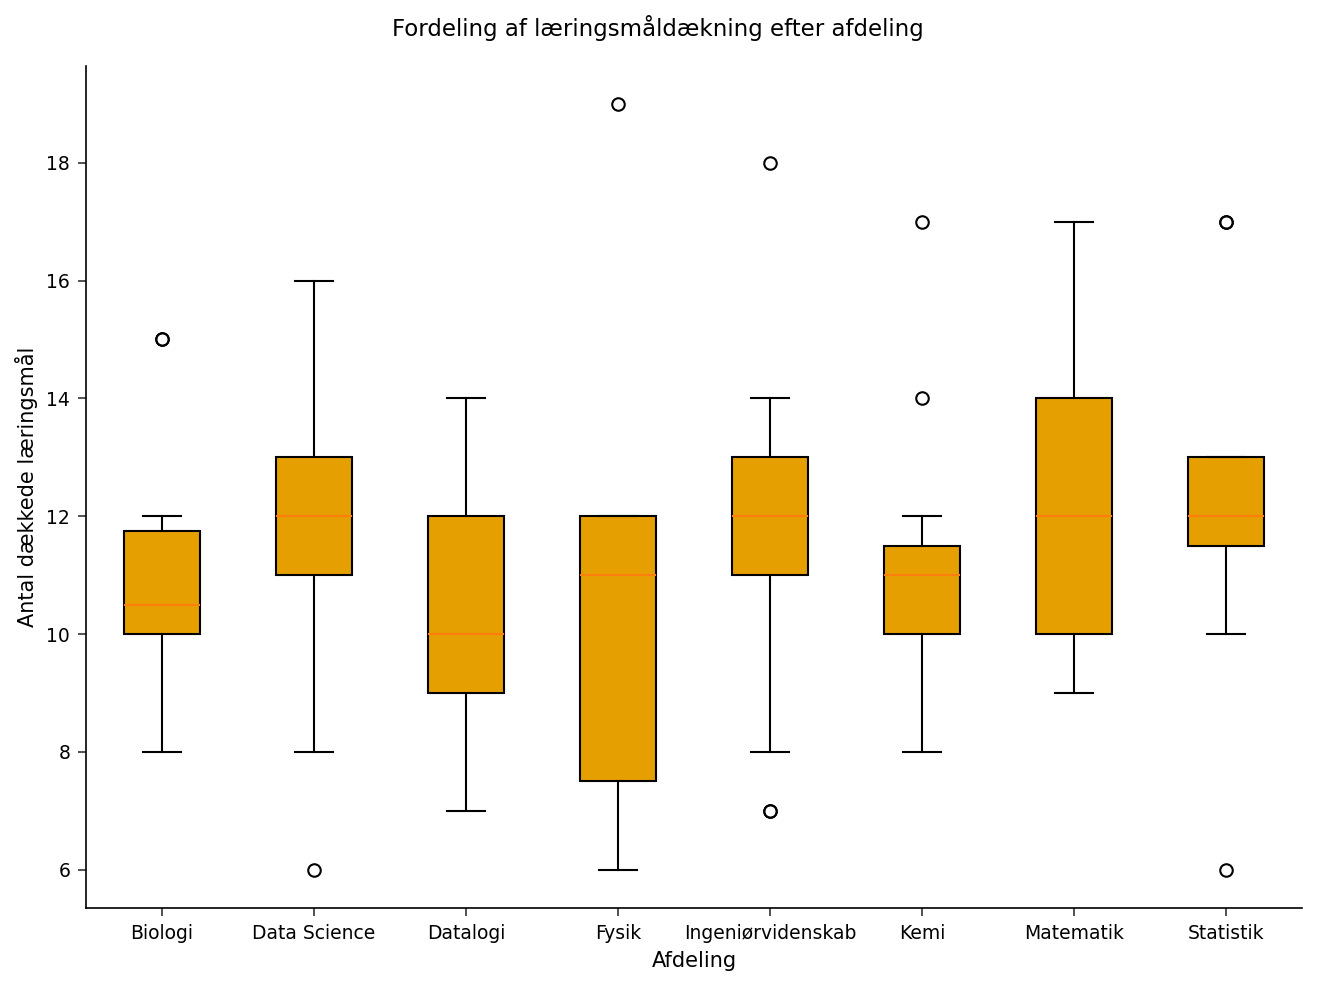

In [4]:
/* --------------------------------------------------------
   Måldækningstæthed pr. afdeling
   -------------------------------------------------------- */
data work.outcome_counts;
    SÆT work.course_outcomes;
    TABEL outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
KØR;

PROCEDURE SGPLOT data=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS MÆRKAT='Antal dækkede læringsmål';
    XAXIS MÆRKAT='Afdeling';
    TITEL 'Fordeling af læringsmåldækning efter afdeling';
KØR;

---

In [5]:
/* --------------------------------------------------------
   Konsolideringspanel: de første 10 kurser i Statistik /
   Data Science (de to mest kvantitativt overlappende
   afdelinger). Omdøb dem P01-P10 med en fortløbende tæller,
   så den kvadratiske OUT=-afstandsmatrix har rene,
   adresserbare kolonner, og beregn derefter hele den
   parvise Jaccard-afstandsmatrix med METHOD=DJACCARD
   (0 = identiske målmængder, 1 = intet fælles mål).
   -------------------------------------------------------- */
data work.panel10;
    SÆT work.course_outcomes(HVOR=(department IN ('Statistik' 'Data Science')));
    BEHOLD_VÆRDI seq 0;
    seq + 1;
    HVIS seq > 10 SÅ stop;
    panel_id = cat('P', SKRIV_V(seq, z2.));
    FJERN seq;
KØR;

PROCEDURE UDSKRIV data=work.panel10 noobs MÆRKAT;
    VARIABEL panel_id course_label department level_code;
    MÆRKAT panel_id = 'Panel-ID' course_label = 'Kursus'
          department = 'Afdeling' level_code = 'Niveau';
    TITEL 'Konsolideringspanel: Statistik- og Data Science-kurser';
KØR;

PROCEDURE distance data=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VARIABEL nominal(lo_1 - lo_40);
    id panel_id;
KØR;

PROCEDURE UDSKRIV data=work.panel_dist noobs;
    TITEL 'Parvis Jaccard-afstandsmatrix (10 kurser)';
KØR;

                                 Konsolideringspanel: Statistik- og Data Science-kurser                                 

Panel-ID   Kursus      Afdeling  Niveau
P01       CRS0003  Data Science     300
P02       CRS0006  Statistik        300
P03       CRS0014  Data Science     300
P04       CRS0015  Statistik        300
P05       CRS0017  Statistik        200
P06       CRS0019  Data Science     100
P07       CRS0022  Statistik        400
P08       CRS0033  Data Science     200
P09       CRS0038  Statistik        100
P10       CRS0040  Statistik        100

                                 Konsolideringspanel: Statistik- og Data Science-kurser                                 

                                       Parvis Jaccard-afstandsmatrix (10 kurser)                                        

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.8571428571  0.82608695


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Omform den kvadratiske afstandsmatrix til en rangordnet
   liste over kursuspar. OUT=-afstandskolonnerne adresseres
   via en eksplicit navneliste (P01 P02 ... P10); kun den
   strengt øvre trekant (kol > række) beholdes, så hvert
   uordnet par optræder én gang, og nuldiagonalen springes
   over. De fem tætteste par er kandidaterne til
   konsolideringsgennemgang.
   -------------------------------------------------------- */
data work.similar_courses;
    SÆT work.panel_dist;
    TABEL d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LÆNGDE course_a course_b $8;
    course_a = _name_;
    row + 1;
    GØR col = 1 TIL 10;
        HVIS col > row SÅ GØR;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            UDDATA;
        SLUT;
    SLUT;
    BEHOLD course_a course_b jaccard_dist;
KØR;

PROCEDURE GENNEMSNIT data=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VARIABEL jaccard_dist;
    MÆRKAT jaccard_dist='Jaccard-afstand';
    TITEL 'Fordeling af parvise Jaccard-afstande (45 kursuspar)';
KØR;

PROCEDURE SORTER data=work.similar_courses; EFTER jaccard_dist; KØR;

data work.top_pairs;
    SÆT work.similar_courses;
    pair_rank = _n_;
    HVIS pair_rank <= 5;
KØR;

PROCEDURE UDSKRIV data=work.top_pairs noobs MÆRKAT;
    VARIABEL pair_rank course_a course_b jaccard_dist;
    MÆRKAT pair_rank = 'Rang' course_a = 'Kursus A'
          course_b = 'Kursus B' jaccard_dist = 'Jaccard-afstand';
    TITEL 'De fem tætteste kursuspar (konsolideringskandidater)';
KØR;

                                  Fordeling af parvise Jaccard-afstande (45 kursuspar)                                  

                                                  The MEANS Procedure

 Variable      Label                  N     Minimum   Lower Quartile      Median        Mean     Maximum
 -------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard-afstand       45       0.588            0.762       0.826       0.818       0.962
 -------------------------------------------------------------------------------------------------------

                                  De fem tætteste kursuspar (konsolideringskandidater)                                  

Rang  Kursus A  Kursus B  Jaccard-afstand
   1  P02       P10                 0.588
   2  P03       P04                   0.6
   3  P03       P05                 0.667
   4  P02       P04                 0.684
   5  P02       P07                 0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                            Udækkede læringsmål pr. afdeling                                            

                                                   The FREQ Procedure

Afdeling              Frequency    Percent
-------------------------------------------
Biologi                       8     26.67
Datalogi                      3     10.00
Fysik                         8     26.67
Ingeniørvidenskab             2      6.67
Kemi                          2      6.67
Matematik                     4     13.33
Statistik                     3     10.00
                                   Eksempel på måldækningshuller (de første 12 af 30)                                   

Afdeling    Udækket mål
Biologi   LO02
Biologi   LO10
Biologi   LO15
Biologi   LO16
Biologi   LO17
Biologi   LO18
Biologi   LO36
Biologi   LO37
Datalogi  LO29
Datalogi  LO35
Datalogi  LO36
Fysik     LO02

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


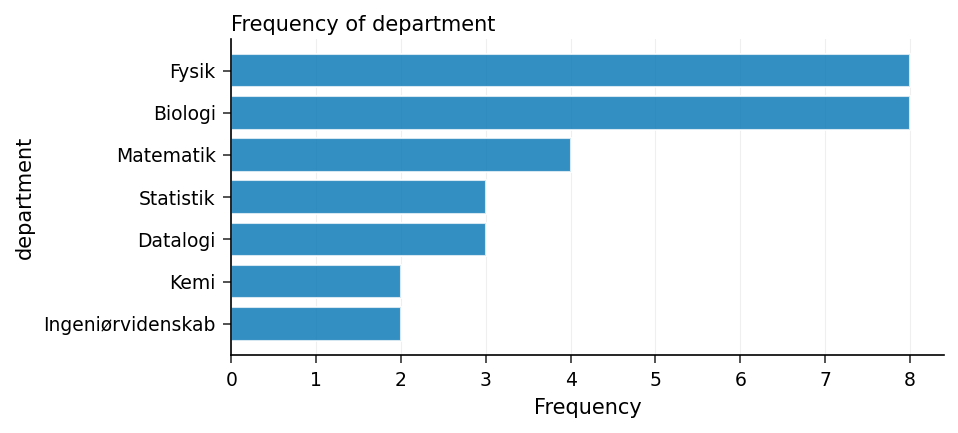

In [7]:
/* --------------------------------------------------------
   Måldækningshuller: læringsmål, som INTET kursus i en
   afdeling dækker. PROC MEANS summerer hvert binært målflag
   inden for afdeling; en sum på nul betyder, at målet
   mangler i den afdelings katalog.
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.course_outcomes sum NOPRINT;
    KLASSE department;
    VARIABEL lo_1 - lo_40;
    UDDATA out=work.dept_coverage(HVOR=(_type_=1))
        sum=lo_1 - lo_40;
KØR;

data work.outcome_gaps;
    SÆT work.dept_coverage;
    TABEL outcomes[40] lo_1 - lo_40;
    GØR lo = 1 TIL 40;
        outcome_id = cat('LO', SKRIV_V(lo, z2.));
        courses_covering = outcomes[lo];
        HVIS courses_covering = 0 SÅ GØR;
            gap_flag = 1;
            UDDATA;
        SLUT;
    SLUT;
    BEHOLD department outcome_id courses_covering gap_flag;
KØR;

PROCEDURE FREKVENSER data=work.outcome_gaps;
    TABLES department / nocum;
    MÆRKAT department='Afdeling';
    TITEL 'Udækkede læringsmål pr. afdeling';
KØR;

PROCEDURE UDSKRIV data=work.outcome_gaps(obs=12) noobs MÆRKAT;
    VARIABEL department outcome_id;
    MÆRKAT department = 'Afdeling' outcome_id = 'Udækket mål';
    TITEL 'Eksempel på måldækningshuller (de første 12 af 30)';
KØR;

---

### Fortolkning

**Konsolideringspanel.** På tværs af de 45 uordnede par i panelet med 10 Statistik-/Data Science-kurser spænder Jaccard-afstanden fra 0.588 til 0.962 med en median på 0.826 (gennemsnit 0.818). Det tætteste par er P02 og P10 med en afstand på 0.588, efterfulgt af P03–P04 på 0.600 og P03–P05 på 0.667. Selv de mest ens kurser adskiller sig stadig på cirka 59% af deres dækkede mål, så dette katalog indeholder **ingen næsten identiske kurser** — der er intet par, et udvalg direkte kunne slå sammen. Den rangordnede liste peger i stedet på de få par, der er værd at underkaste en manuel pensumsammenligning inden næste katalogcyklus; parrene med størst afstand (nær 0.962) bekræfter, at Statistik- og Data Science-kurser, trods deres fælles afdelingsnaboskab, spænder over reelt forskellige målmængder.

**Målhuller.** Tredive huller pr. afdeling og mål dukker op på tværs af kataloget. De laboratorietunge discipliner bærer flest: **Biologi** og **Fysik** efterlader hver 8 af de 40 akkrediteringsmål udækkede, efterfulgt af **Matematik** (4). De kvantitative afdelinger er bedst dækket — **Kemi** og **Ingeniørvidenskab** mangler kun 2 mål hver. Disse huller er de naturlige mål for udvikling af nye kurser eller krydsregistrering: et mål, der mangler i en hel afdeling, er en dækningsrisiko ved akkrediteringsfornyelse, mens konsolideringslisten adresserer det modsatte problem med overflødigt arbejde. Tilsammen lader de to artefakter udvalget stramme kataloget op fra begge ender — trimme overlap og udfylde ørkener — med ét mængdebaseret afstandsmål.

---

In [8]:
/* --------------------------------------------------------
   Eksportér de rangordnede konsolideringskandidater og
   afdelingernes måldækningshulkort til læseplansudvalget.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>